In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [127]:
EUG_welfare = pd.read_csv("data/welfare.csv")
SPR_welfare = pd.read_csv("data/SPR_welfare.csv")

In [128]:
EUG_welfare.head()

,Unnamed: 0,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year,Institution
0,0,15000003,2015-01-01 00:01:05,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,3J79,1,1,1,2015,CAHOOTS
1,1,15000052,2015-01-01 00:38:37,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,3594,1,1,5,3J79,1,1,1,2015,CAHOOTS
2,2,15000092,2015-01-01 01:28:40,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,1824,1,1,5,5B44,1,1,1,2015,EPD
3,3,15000107,2015-01-01 01:41:40,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,1285,1,1,5,3J79,1,1,1,2015,CAHOOTS
4,4,15000435,2015-01-01 15:09:21,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,4369,1,1,7,3J79,1,1,1,2015,CAHOOTS


In [129]:
calls = EUG_welfare.groupby(['year','month','Institution'])['nature'].count()
calls

year  month  Institution
2015  1      CAHOOTS        138
             EPD            164
             Neither         23
      2      CAHOOTS        154
             EPD            148
                           ... 
2025  10     Neither        144
      11     EPD            336
             Neither        112
      12     EPD            400
             Neither         82
Name: nature, Length: 388, dtype: int64

In [130]:
#counting the rows of calls each month from spd, cahoots, and neither
spr_calls = SPR_welfare.groupby(['year','month','Institution'])['Initial Call Type'].count()
spr_calls

year  month  Institution
2015  1      CAHOOTS         24
             Neither         14
             SPD             81
      2      CAHOOTS         61
             Neither         12
                           ... 
2025  11     Neither         16
             SPD            133
      12     CAHOOTS         87
             Neither         22
             SPD            125
Name: Initial Call Type, Length: 396, dtype: int64

In [131]:
calldf = calls.to_frame()
spr_calldf = spr_calls.to_frame()

In [132]:
calldf.reset_index(inplace=True)
spr_calldf.reset_index(inplace=True)

In [133]:
calldf['date'] = pd.to_datetime(calldf[['month','year']].assign(DAY=1))
spr_calldf['date'] = pd.to_datetime(spr_calldf[['month','year']].assign(DAY=1))

In [134]:
#calldf.columns
calldf

,year,month,Institution,nature,date
0,2015,1,CAHOOTS,138,2015-01-01
1,2015,1,EPD,164,2015-01-01
2,2015,1,Neither,23,2015-01-01
3,2015,2,CAHOOTS,154,2015-02-01
4,2015,2,EPD,148,2015-02-01
...,...,...,...,...,...
383,2025,10,Neither,144,2025-10-01
384,2025,11,EPD,336,2025-11-01
385,2025,11,Neither,112,2025-11-01
386,2025,12,EPD,400,2025-12-01


In [135]:
spr_calldf.columns

Index(['year', 'month', 'Institution', 'Initial Call Type', 'date'], dtype='object')

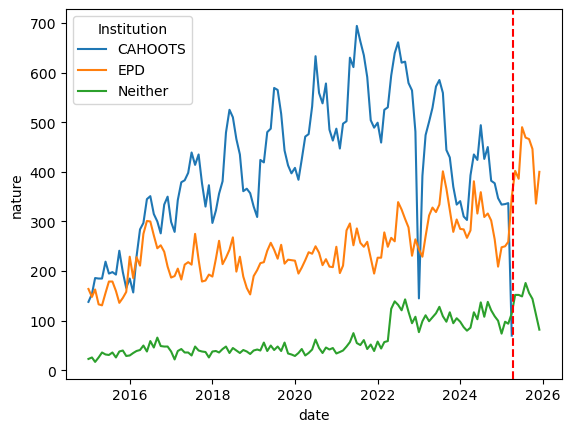

In [136]:
#this can't be right. this says cahoots didn't answer any welfare calls after...2002?
sns.lineplot(data=calldf,x = 'date', y = 'nature', hue='Institution')
plt.axvline(x=pd.to_datetime('2025-04-08'), color='red', linestyle='--')

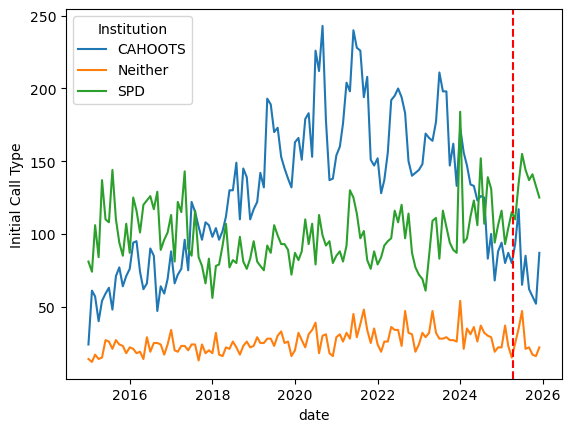

In [137]:
sns.lineplot(data=spr_calldf,x = 'date', y = 'Initial Call Type', hue='Institution')
plt.axvline(x=pd.to_datetime('2025-04-08'), color='red', linestyle='--')

In [138]:
EUG_welfare

,Unnamed: 0,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year,Institution
0,0,15000003,2015-01-01 00:01:05,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,3J79,1,1,1,2015,CAHOOTS
1,1,15000052,2015-01-01 00:38:37,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,3594,1,1,5,3J79,1,1,1,2015,CAHOOTS
2,2,15000092,2015-01-01 01:28:40,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,1824,1,1,5,5B44,1,1,1,2015,EPD
3,3,15000107,2015-01-01 01:41:40,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,1285,1,1,5,3J79,1,1,1,2015,CAHOOTS
4,4,15000435,2015-01-01 15:09:21,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,4369,1,1,7,3J79,1,1,1,2015,CAHOOTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92747,93210,25327100,2025-12-31 17:12:02,NaN,PHONE,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,NaN,NaN,4147,0,0,4,NaN,0,0,12,2025,Neither
92748,93211,25327137,2025-12-31 17:56:18,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,5655.0,6292.0,8294,1,1,3,4U72,2,2,12,2025,EPD
92749,93212,25327208,2025-12-31 20:23:13,NaN,PHONE,CHECK WELFARE,WELC,WELFARE CHECK DONE,2828.0,3001.0,3451,1,1,3,5E56,2,2,12,2025,EPD
92750,93213,25327228,2025-12-31 20:50:01,NaN,W911,CHECK WELFARE,DIS,DISREGARD,354.0,740.0,818,1,1,3,4U72,2,2,12,2025,EPD


In [139]:
total_EUG_calls = EUG_welfare.groupby(['year','month'])['nature'].count()
total_SPR_calls = SPR_welfare.groupby(['year','month'])['Initial Call Type'].count()

In [140]:
total_EUG_calls = total_EUG_calls.to_frame()
total_SPR_calls = total_SPR_calls.to_frame()
total_EUG_calls.reset_index(inplace=True)
total_SPR_calls.reset_index(inplace=True)

In [141]:
total_EUG_calls['date'] = pd.to_datetime(total_EUG_calls[['month','year']].assign(DAY=1))
total_SPR_calls['date'] = pd.to_datetime(total_SPR_calls[['month','year']].assign(DAY=1))
total_SPR_calls

,year,month,Initial Call Type,date
0,2015,1,119,2015-01-01
1,2015,2,147,2015-02-01
2,2015,3,180,2015-03-01
3,2015,4,138,2015-04-01
4,2015,5,206,2015-05-01
...,...,...,...,...
127,2025,8,250,2025-08-01
128,2025,9,221,2025-09-01
129,2025,10,215,2025-10-01
130,2025,11,201,2025-11-01


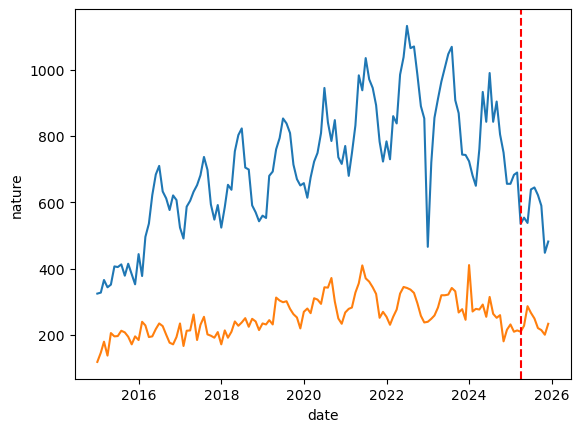

In [187]:
sns.lineplot(data=total_EUG_calls,x = 'date', y = 'nature')
sns.lineplot(data=total_SPR_calls,x = 'date', y = 'Initial Call Type') #if you want to see both at once
plt.axvline(x=pd.to_datetime('2025-04-08'), color='red', linestyle='--')

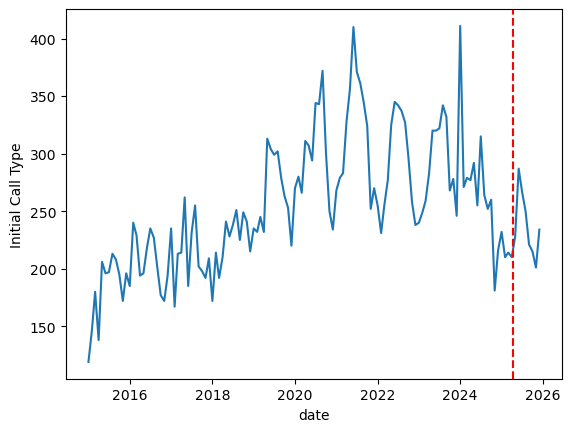

In [186]:
sns.lineplot(data=total_SPR_calls,x = 'date', y = 'Initial Call Type')
plt.axvline(x=pd.to_datetime('2025-04-08'), color='red', linestyle='--')

In [144]:
test = calldf[(calldf['year'] == 2023) & (calldf['Institution'] == 'CAHOOTS')]
test

,year,month,Institution,nature,date
288,2023,1,CAHOOTS,145,2023-01-01
291,2023,2,CAHOOTS,392,2023-02-01
294,2023,3,CAHOOTS,474,2023-03-01
297,2023,4,CAHOOTS,501,2023-04-01
300,2023,5,CAHOOTS,529,2023-05-01
303,2023,6,CAHOOTS,572,2023-06-01
306,2023,7,CAHOOTS,585,2023-07-01
309,2023,8,CAHOOTS,559,2023-08-01
312,2023,9,CAHOOTS,444,2023-09-01
315,2023,10,CAHOOTS,429,2023-10-01


<Axes: xlabel='month', ylabel='nature'>

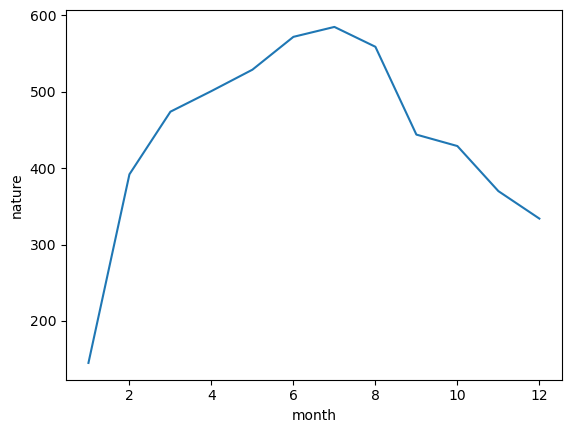

In [145]:
sns.lineplot(data=test,x = 'month', y = 'nature')

<Axes: xlabel='month', ylabel='nature'>

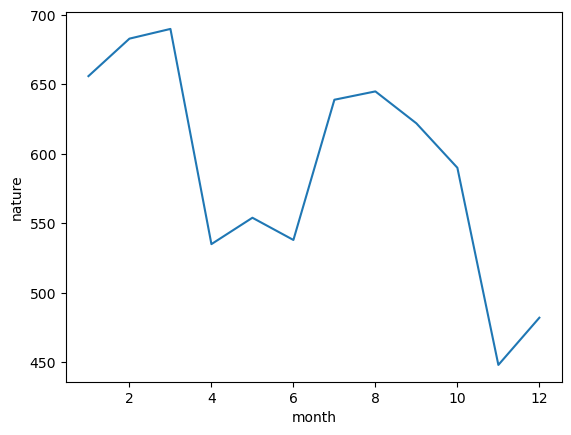

In [146]:
test2 = total_EUG_calls[total_EUG_calls['year'] == 2025]
sns.lineplot(data=test2,x = 'month', y = 'nature')

#### Box Plots

In [164]:
#divide into two dataframes based on when CAHOOTS stopped operating
EUG_welfare['calltime'][0]

Timestamp('2015-01-01 00:01:05')

In [151]:
EUG_welfare['calltime'] = EUG_welfare['calltime'].apply(
    lambda x: dt.datetime.strptime(x,'%Y-%m-%d %H:%M:%S'))

In [156]:
#making a datetime object for CAHOOTS stopping
CAHOOTS_stop_date = pd.to_datetime('2025-04-08 00:00:00')

In [161]:
EUG_welfare['CAHOOTS active'] = np.where(EUG_welfare['calltime'] < CAHOOTS_stop_date,1,0)
EUG_welfare

,Unnamed: 0,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,...,disp,arrv,priority,primeunit,units_dispd,units_arrived,month,year,Institution,CAHOOTS active
0,0,15000003,2015-01-01 00:01:05,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,...,1,1,5,3J79,1,1,1,2015,CAHOOTS,1
1,1,15000052,2015-01-01 00:38:37,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,2402.0,2941.0,...,1,1,5,3J79,1,1,1,2015,CAHOOTS,1
2,2,15000092,2015-01-01 01:28:40,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,1305.0,1524.0,...,1,1,5,5B44,1,1,1,2015,EPD,1
3,3,15000107,2015-01-01 01:41:40,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,600.0,926.0,...,1,1,5,3J79,1,1,1,2015,CAHOOTS,1
4,4,15000435,2015-01-01 15:09:21,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,3018.0,3605.0,...,1,1,7,3J79,1,1,1,2015,CAHOOTS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92747,93210,25327100,2025-12-31 17:12:02,NaN,PHONE,CHECK WELFARE,DDIS,DISREGARDED BY DISPATCH,NaN,NaN,...,0,0,4,NaN,0,0,12,2025,Neither,0
92748,93211,25327137,2025-12-31 17:56:18,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,5655.0,6292.0,...,1,1,3,4U72,2,2,12,2025,EPD,0
92749,93212,25327208,2025-12-31 20:23:13,NaN,PHONE,CHECK WELFARE,WELC,WELFARE CHECK DONE,2828.0,3001.0,...,1,1,3,5E56,2,2,12,2025,EPD,0
92750,93213,25327228,2025-12-31 20:50:01,NaN,W911,CHECK WELFARE,DIS,DISREGARD,354.0,740.0,...,1,1,3,4U72,2,2,12,2025,EPD,0


In [165]:
boxy = EUG_welfare[(EUG_welfare['Institution'] == 'EPD') | (EUG_welfare['Institution'] == 'CAHOOTS')]

<Axes: xlabel='Institution', ylabel='secs_to_arrv'>

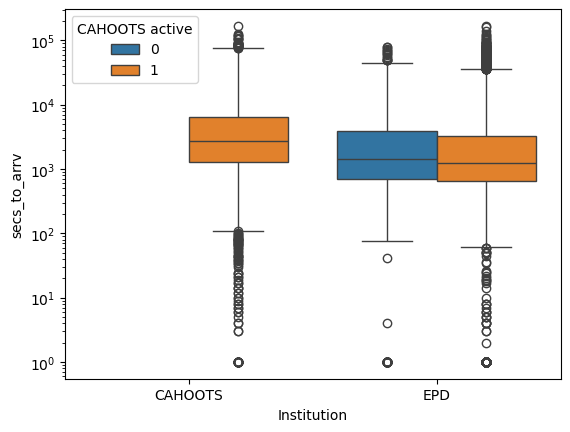

In [166]:
sns.boxplot(x="Institution", y="secs_to_arrv", data=boxy,log_scale = True,hue='CAHOOTS active')

#### Disposition Histogram

<Axes: xlabel='Count', ylabel='closed_as'>

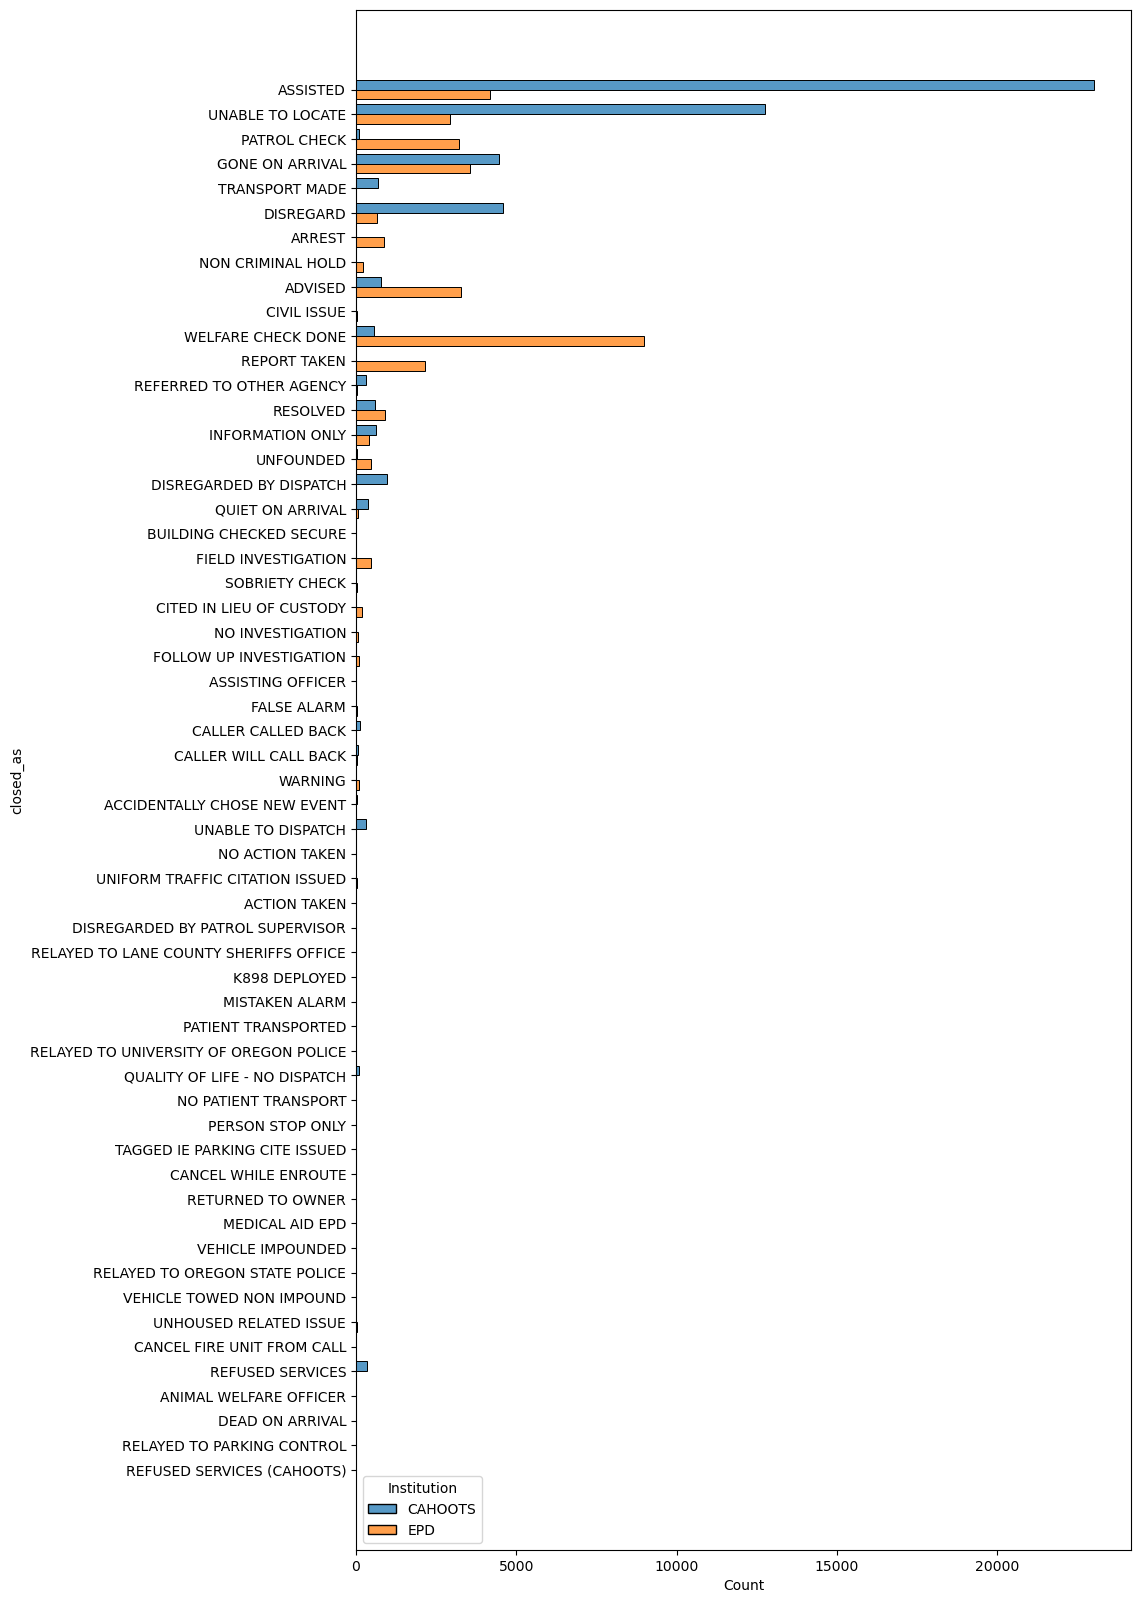

In [172]:
plt.figure(figsize=(10,20))
sns.histplot(data=boxy, y='closed_as',hue='Institution',multiple='dodge',shrink=0.8)

In [175]:
#testing DiD analysis
data = {'group': ['control']*4 + ['treat']*4,
        'time': ['pre', 'post']*4,
        'outcome': [5, 6, 7, 8, 8, 10, 12, 15]}
data

{'group': ['control',
  'control',
  'control',
  'control',
  'treat',
  'treat',
  'treat',
  'treat'],
 'time': ['pre', 'post', 'pre', 'post', 'pre', 'post', 'pre', 'post'],
 'outcome': [5, 6, 7, 8, 8, 10, 12, 15]}

In [176]:
df = pd.DataFrame(data)
df

,group,time,outcome
0,control,pre,5
1,control,post,6
2,control,pre,7
3,control,post,8
4,treat,pre,8
5,treat,post,10
6,treat,pre,12
7,treat,post,15


In [180]:
#one hot encoding, eh?
df['D'] = df['group'].apply(lambda x: 1 if x == 'treat' else 0)
df['T'] = df['time'].apply(lambda x: 1 if x == 'post' else 0)

# Interaction term
df['D_T'] = df['D'] * df['T'] #huh
df

,group,time,outcome,D,T,D_T
0,control,pre,5,0,0,0
1,control,post,6,0,1,0
2,control,pre,7,0,0,0
3,control,post,8,0,1,0
4,treat,pre,8,1,0,0
5,treat,post,10,1,1,1
6,treat,pre,12,1,0,0
7,treat,post,15,1,1,1


In [182]:
# Run OLS regression
model = smf.ols('outcome ~ D + T + D_T', data=df).fit()

# Display summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     2.850
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.169
Time:                        21:50:20   Log-Likelihood:                -15.828
No. Observations:                   8   AIC:                             39.66
Df Residuals:                       4   BIC:                             39.97
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.0000      1.750      3.429      0.0

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)
